<a href="https://colab.research.google.com/github/halimahsalsabila/Sentiment-Analysis/blob/main/riset_part_sekian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import KFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [ ]:
#panggil data
df = pd.read_csv('/content/hasil-labelin_DAY6 (7).csv')
df.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,...,case_folding,tokenisasi,normalisasi,negation_converted_text,stopword_removal,stemming,to_sentence,english,polarity,sentiment
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,...,fakta fakta day yang bakal konser di tiga kota...,"['fakta', 'fakta', 'day', 'yang', 'bakal', 'ko...","['fakta', 'fakta', 'day', 'yang', 'bakal', 'ko...","['fakta', 'fakta', 'day', 'yang', 'bakal', 'ko...","['fakta', 'fakta', 'day', 'yang', 'konser', 'k...","['fakta', 'fakta', 'day', 'yang', 'konser', 'k...",fakta fakta day yang konser kota indonesia tem...,Facts of Day that will concert in three cities...,0.000000,Negative
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,Indonesia,762,94,1597,...,temen kantor w yang suka day dan jarang ngetwe...,"['temen', 'kantor', 'w', 'yang', 'suka', 'day'...","['teman', 'kantor', 'gue', 'yang', 'suka', 'da...","['teman', 'kantor', 'gue', 'yang', 'suka', 'da...","['teman', 'kantor', 'gue', 'yang', 'suka', 'da...","['teman', 'kantor', 'gue', 'yang', 'suka', 'da...",teman kantor gue yang suka day jarang ngetweet...,Friends of the office W who like to day and ra...,0.100000,Positive
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,...,haloo temen temen myday kalo masih bingung mau...,"['haloo', 'temen', 'temen', 'myday', 'kalo', '...","['haloo', 'teman', 'teman', 'myday', 'kalo', '...","['haloo', 'teman', 'teman', 'myday', 'kalo', '...","['haloo', 'teman', 'teman', 'myday', 'bingung'...","['haloo', 'teman', 'teman', 'myday', 'bingung'...",haloo teman teman myday bingung mau makan kons...,"Hello, my friend MyDay, if you're still confus...",-0.400000,Negative
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,Indonesia,0,0,0,...,ini detail dan spesifikasi contoh desainnya ya...,"['ini', 'detail', 'dan', 'spesifikasi', 'conto...","['ini', 'detail', 'dan', 'spesifikasi', 'conto...","['ini', 'detail', 'dan', 'spesifikasi', 'conto...","['detail', 'spesifikasi', 'contoh', 'desainnya...","['detail', 'spesifikasi', 'contoh', 'desain', ...",detail spesifikasi contoh desain form pesan da...,This is the details and specifications of the ...,0.000000,Negative
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,Indonesia,25,5,152,...,yang bikin tiket konser day pantas untuk dibel...,"['yang', 'bikin', 'tiket', 'konser', 'day', 'p...","['yang', 'bikin', 'tiket', 'konser', 'day', 'p...","['yang', 'bikin', 'tiket', 'konser', 'day', 'p...","['yang', 'bikin', 'tiket', 'konser', 'day', 'd...","['yang', 'bikin', 'tiket', 'konser', 'day', 'b...",yang bikin tiket konser day beli musikalitas d...,What makes a day concert ticket deserves to be...,0.066667,Positive


In [ ]:
# Misal data Anda memiliki kolom 'to_sentence' (teks) dan 'sentiment' (label)
X = df['to_sentence']  # Kolom yang berisi teks (fitur)
y = df['sentiment']    # Kolom yang berisi label (sentimen)

In [ ]:
# Membagi data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train)
print("X_test:", X_test)

X_train: 2649    celios kritik guna uang pribadi prabowo progra...
1451    selamat sore mohon merefund customer forever y...
3329     dengar suruh makan menu mbak belum tentu ketelen
1691    refund kirim album wajib lain yang penuh yuk s...
4305    program hilang efisiensi makan siang gratis ra...
                              ...                        
4426    komitmen prabowo wujud generasi emas program m...
466     yeppeoseo video jadi sila cek fokus youngk day...
3092    serius program mbak ubah nama makan gizi grati...
3772                       moga program mbak jalan lancar
860     riil meng ndud youngk day injakarta day foreve...
Name: to_sentence, Length: 3834, dtype: object
X_test: 561     youngk ment notice my day enggak enak badan wa...
893     moga day bareng bareng anak cucu moga ada kons...
1684                    gila duit gue gila balikin mecima
705     day habis selesai konser indonesia yang enggak...
1873    selamat pagi cim jangan lupa refund mecimatunt...
        

In [ ]:
# Inisialisasi TF-IDF Vectorizer
tfidf = TfidfVectorizer()

# Fit dan transform data pelatihan dan uji
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Menampilkan hasil representasi numerik untuk data pelatihan
print("X_train_tfidf:")
print(X_train_tfidf.toarray())

# Menampilkan fitur yang dihasilkan oleh TF-IDF
print("Fitur TF-IDF:", tfidf.get_feature_names_out())

# Jika ingin menampilkan data dalam format DataFrame
import pandas as pd
df_train_tfidf = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf.get_feature_names_out())
print(df_train_tfidf)


X_train_tfidf:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Fitur TF-IDF: ['aa' 'aaa' 'aaaww' ... 'zul' 'zulhas' 'zuzu']
       aa  aaa  aaaww  aah  aakk  aamiinn  abadi  abah  abai  abal  ...  \
0     0.0  0.0    0.0  0.0   0.0      0.0    0.0   0.0   0.0   0.0  ...   
1     0.0  0.0    0.0  0.0   0.0      0.0    0.0   0.0   0.0   0.0  ...   
2     0.0  0.0    0.0  0.0   0.0      0.0    0.0   0.0   0.0   0.0  ...   
3     0.0  0.0    0.0  0.0   0.0      0.0    0.0   0.0   0.0   0.0  ...   
4     0.0  0.0    0.0  0.0   0.0      0.0    0.0   0.0   0.0   0.0  ...   
...   ...  ...    ...  ...   ...      ...    ...   ...   ...   ...  ...   
3829  0.0  0.0    0.0  0.0   0.0      0.0    0.0   0.0   0.0   0.0  ...   
3830  0.0  0.0    0.0  0.0   0.0      0.0    0.0   0.0   0.0   0.0  ...   
3831  0.0  0.0    0.0  0.0   0.0      0.0    0.0   0.0   0.0   0.0  ...   
3832  0.0  0.0    

In [ ]:
# Terapkan SMOTE pada data latih untuk menyeimbangkan kelas
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

# Menampilkan distribusi kelas sebelum dan setelah SMOTE
print("Distribusi kelas sebelum SMOTE:", Counter(y_train))
print("Distribusi kelas setelah SMOTE:", Counter(y_train_resampled))

Distribusi kelas sebelum SMOTE: Counter({'Positive': 2417, 'Negative': 1417})
Distribusi kelas setelah SMOTE: Counter({'Positive': 2417, 'Negative': 2417})


Text(0, 0.5, 'Jumlah')

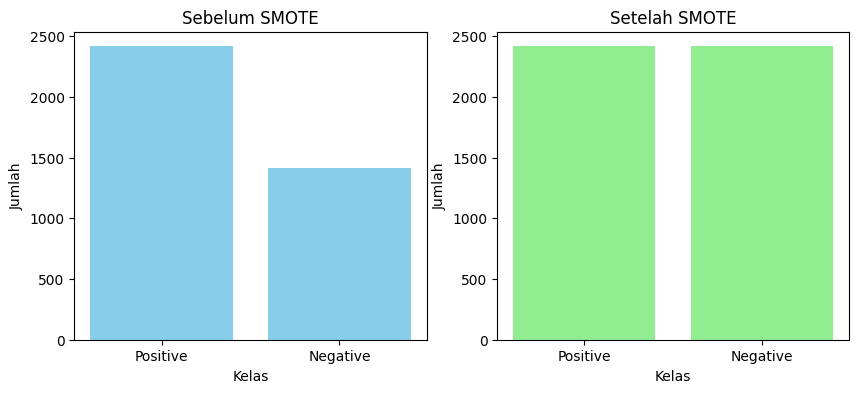

In [ ]:
# Visualisasi distribusi kelas
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Sebelum SMOTE
ax[0].bar(Counter(y_train).keys(), Counter(y_train).values(), color='skyblue')
ax[0].set_title("Sebelum SMOTE")
ax[0].set_xlabel("Kelas")
ax[0].set_ylabel("Jumlah")

# Setelah SMOTE
ax[1].bar(Counter(y_train_resampled).keys(), Counter(y_train_resampled).values(), color='lightgreen')
ax[1].set_title("Setelah SMOTE")
ax[1].set_xlabel("Kelas")
ax[1].set_ylabel("Jumlah")

In [ ]:
# Deklarasi variabel estimators sebagai penampung sub model
estimators = []

# Model KNN terbaik (misalnya dari uji sebelumnya)
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_knn3 = knn3.predict(X_test_tfidf) # Use X_test_tfidf here
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_knn5 = knn5.predict(X_test_tfidf) # Use X_test_tfidf here
knn7 = KNeighborsClassifier(n_neighbors=7)
knn7.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_knn7 = knn7.predict(X_test_tfidf) # Use X_test_tfidf here
knn8 = KNeighborsClassifier(n_neighbors=8)
knn8.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_knn8 = knn8.predict(X_test_tfidf) # Use X_test_tfidf here
knn9 = KNeighborsClassifier(n_neighbors=9)
knn9.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_knn9 = knn9.predict(X_test_tfidf) # Use X_test_tfidf here
knn10 = KNeighborsClassifier(n_neighbors=10)
knn10.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_knn10 = knn10.predict(X_test_tfidf) # Use X_test_tfidf here
estimators.append(('knn3', knn3))
estimators.append(('knn5', knn5))
estimators.append(('knn7', knn7))
estimators.append(('knn8', knn8))
estimators.append(('knn9', knn9))
estimators.append(('knn10', knn10))

In [ ]:
estimators = []

# Model SVM RBF terbaik hasil eksperimen
svm1 = SVC(kernel='rbf', C=1, gamma=0.01, probability=True) # Added probability=True
svm1.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_svm1 = svm1.predict(X_test_tfidf) # Use X_test_tfidf here
svm2 = SVC(kernel='rbf', C=100, gamma=0.001, probability=True) # Added probability=True
svm2.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_svm2 = svm2.predict(X_test_tfidf) # Use X_test_tfidf here
svm3 = SVC(kernel='rbf', C=10, gamma=0.1, probability=True) # Added probability=True
svm3.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_svm3 = svm3.predict(X_test_tfidf) # Use X_test_tfidf here
svm4 = SVC(kernel='rbf', C=100, gamma=0.1, probability=True) # Added probability=True
svm4.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_svm4 = svm4.predict(X_test_tfidf) # Use X_test_tfidf here
svm5 = SVC(kernel='rbf', C=1000, gamma=0.001, probability=True)
svm5.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_svm5 = svm5.predict(X_test_tfidf) # Use X_test_tfidf here
svm6 = SVC(kernel='rbf', C=10000, gamma=0.1, probability=True)
svm6.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
pred_svm6 = svm6.predict(X_test_tfidf) # Use X_test_tfidf here
estimators.append(('svm1', svm1))
estimators.append(('svm2', svm2))
estimators.append(('svm3', svm3))
estimators.append(('svm4', svm4))
estimators.append(('svm5', svm5))
estimators.append(('svm6', svm6))

In [ ]:
# MODEL ENSEMBLE DENGAN METODE VOTING
ensemble = VotingClassifier(estimators)
ensemble.fit(X_train_tfidf, y_train) # Use X_train_tfidf here
voting_pred4 = ensemble.predict(X_test_tfidf) # Use X_test_tfidf here

cols = {
    'Y True' : y_test,
    'KNN3' : knn3.predict(X_test_tfidf), # Use X_test_tfidf here
    'KNN5' : knn5.predict(X_test_tfidf), # Use X_test_tfidf here
    'KNN7' : knn7.predict(X_test_tfidf), # Use X_test_tfidf here
    'KNN8' : knn8.predict(X_test_tfidf), # Use X_test_tfidf here
    'KNN9' : knn9.predict(X_test_tfidf), # Use X_test_tfidf here
    'KNN10' : knn10.predict(X_test_tfidf), # Use X_test_tfidf here
    'SVM1' : svm1.predict(X_test_tfidf), # Use X_test_tfidf here
    'SVM2' : svm2.predict(X_test_tfidf), # Use X_test_tfidf here
    'SVM3' : svm3.predict(X_test_tfidf), # Use X_test_tfidf here
    'SVM4' : svm4.predict(X_test_tfidf), # Use X_test_tfidf here
    'SVM5' : svm5.predict(X_test_tfidf), # Use X_test_tfidf here
    'SVM6' : svm6.predict(X_test_tfidf), # Use X_test_tfidf here
    'Voting' : voting_pred4
}

print("Prediksi pada setiap Algoritma")
pd.DataFrame(cols)

Prediksi pada setiap Algoritma


,Y True,KNN3,KNN5,KNN7,KNN8,KNN9,KNN10,SVM1,SVM2,SVM3,SVM4,SVM5,SVM6,Voting
561,Positive,Negative,Negative,Negative,Negative,Negative,Negative,Positive,Positive,Positive,Negative,Positive,Negative,Positive
893,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive
1684,Negative,Negative,Negative,Negative,Negative,Negative,Negative,Positive,Negative,Negative,Negative,Negative,Negative,Negative
705,Negative,Positive,Negative,Negative,Negative,Negative,Negative,Positive,Positive,Negative,Negative,Negative,Negative,Negative
1873,Positive,Negative,Negative,Negative,Negative,Negative,Negative,Positive,Negative,Positive,Positive,Positive,Positive,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859,Positive,Negative,Negative,Negative,Negative,Negative,Negative,Positive,Negative,Positive,Positive,Positive,Positive,Positive
4283,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive,Positive
650,Negative,Negative,Negative,Negative,Negative,Negative,Negative,Positive,Positive,Negative,Negative,Negative,Negative,Negative
2302,Positive,Positive,Positive,Positive,Negative,Positive,Negative,Positive,Positive,Negative,Positive,Negative,Positive,Positive


In [ ]:
df_hasil = pd.DataFrame(cols)

# Buat kolom baru: apakah voting sama dengan label asli
df_hasil['voting_correct'] = df_hasil['Voting'] == df_hasil['Y True']

# Hitung jumlah benar dan salah
voting_accuracy_counts = df_hasil['voting_correct'].value_counts()

# Tampilkan
print("Jumlah Voting Positive vs Negative:")
print(voting_accuracy_counts)

Jumlah Voting Positive vs Negative:
voting_correct
True     751
False    208
Name: count, dtype: int64


/tmp/ipython-input-2118873279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=voting_accuracy_counts.index.map({True: 'Positive', False: 'Negative'}),


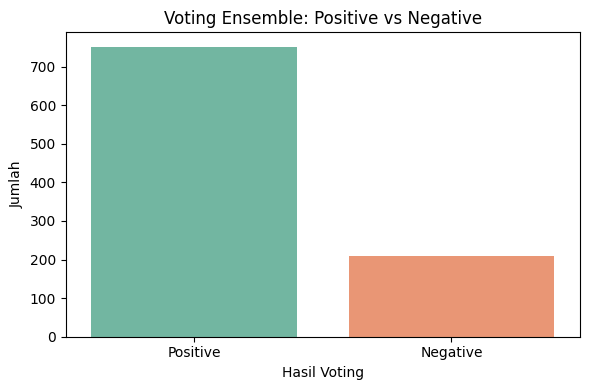

In [ ]:
# Plot bar chart jumlah voting benar vs salah
plt.figure(figsize=(6, 4))
sns.barplot(x=voting_accuracy_counts.index.map({True: 'Positive', False: 'Negative'}),
            y=voting_accuracy_counts.values, palette='Set2')
plt.title('Voting Ensemble: Positive vs Negative')
plt.xlabel('Hasil Voting')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

In [ ]:
df_hasil = pd.DataFrame(cols)

# Simpan ke file Excel
df_hasil.to_csv("hasil_prediksi_ensemble.csv", index=False)

print("Hasil berhasil disimpan ke 'hasil_prediksi_ensemble.csv'")

Hasil berhasil disimpan ke 'hasil_prediksi_ensemble.csv'


In [ ]:
df_hasil= pd.DataFrame(cols)

cols = ['Y True', 'KNN3', 'KNN5', 'KNN7', 'KNN8', 'KNN9', 'KNN10', 'SVM1', 'SVM2', 'SVM3', 'SVM4', 'SVM5', 'SVM6', 'Voting']

for col in cols:
    print(f"\nHasil prediksi untuk kolom: {col}")
    print(df_hasil[col].value_counts())


Hasil prediksi untuk kolom: Y True
Y True
Positive    582
Negative    377
Name: count, dtype: int64

Hasil prediksi untuk kolom: KNN3
KNN3
Positive    572
Negative    387
Name: count, dtype: int64

Hasil prediksi untuk kolom: KNN5
KNN5
Positive    589
Negative    370
Name: count, dtype: int64

Hasil prediksi untuk kolom: KNN7
KNN7
Positive    588
Negative    371
Name: count, dtype: int64

Hasil prediksi untuk kolom: KNN8
KNN8
Positive    524
Negative    435
Name: count, dtype: int64

Hasil prediksi untuk kolom: KNN9
KNN9
Positive    599
Negative    360
Name: count, dtype: int64

Hasil prediksi untuk kolom: KNN10
KNN10
Positive    545
Negative    414
Name: count, dtype: int64

Hasil prediksi untuk kolom: SVM1
SVM1
Positive    959
Name: count, dtype: int64

Hasil prediksi untuk kolom: SVM2
SVM2
Positive    766
Negative    193
Name: count, dtype: int64

Hasil prediksi untuk kolom: SVM3
SVM3
Positive    605
Negative    354
Name: count, dtype: int64

Hasil prediksi untuk kolom: SVM4
SVM4
P

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asumsi df_hasil berisi kolom: 'Y True', 'Pred KNN', 'Pred SVM', 'Voting', dll.
# Ambil semua kolom prediksi model (kecuali 'Y True' dan 'voting_correct')
model_columns = [col for col in df_hasil.columns if col not in ['Y True', 'voting_correct']]

# Siapkan dictionary hasil evaluasi
evaluation_results = {
    'Model': [],
    'Akurasi (%)': [],
    'Presisi (%)': [],
    'Recall (%)': [],
    'F1-Score (%)': []
}

# Hitung metrik untuk tiap model
for model in model_columns:
    y_pred = df_hasil[model]
    y_true = df_hasil['Y True']

    evaluation_results['Model'].append(model)
    evaluation_results['Akurasi (%)'].append(accuracy_score(y_true, y_pred) * 100)
    evaluation_results['Presisi (%)'].append(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100)
    evaluation_results['Recall (%)'].append(recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100)
    evaluation_results['F1-Score (%)'].append(f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100)

# Buat DataFrame hasil evaluasi
eval_df = pd.DataFrame(evaluation_results)
eval_df = eval_df.set_index('Model')
eval_df = eval_df.round(2)
display(eval_df)


,Akurasi (%),Presisi (%),Recall (%),F1-Score (%)
Model,,,,
KNN3,69.97,70.12,69.97,70.04
KNN5,72.99,72.91,72.99,72.95
KNN7,71.01,70.93,71.01,70.97
KNN8,71.22,72.28,71.22,71.49
KNN9,70.91,70.70,70.91,70.78
KNN10,70.07,70.70,70.07,70.28
SVM1,60.69,36.83,60.69,45.84
SVM2,71.85,73.26,71.85,69.22
SVM3,79.25,79.09,79.25,79.12


In [ ]:
eval_df.to_csv('hasil_evaluasi_model.csv')

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
eval_df.to_csv(f'hasil_evaluasi_model_{timestamp}.csv')

<Figure size 1200x600 with 0 Axes>

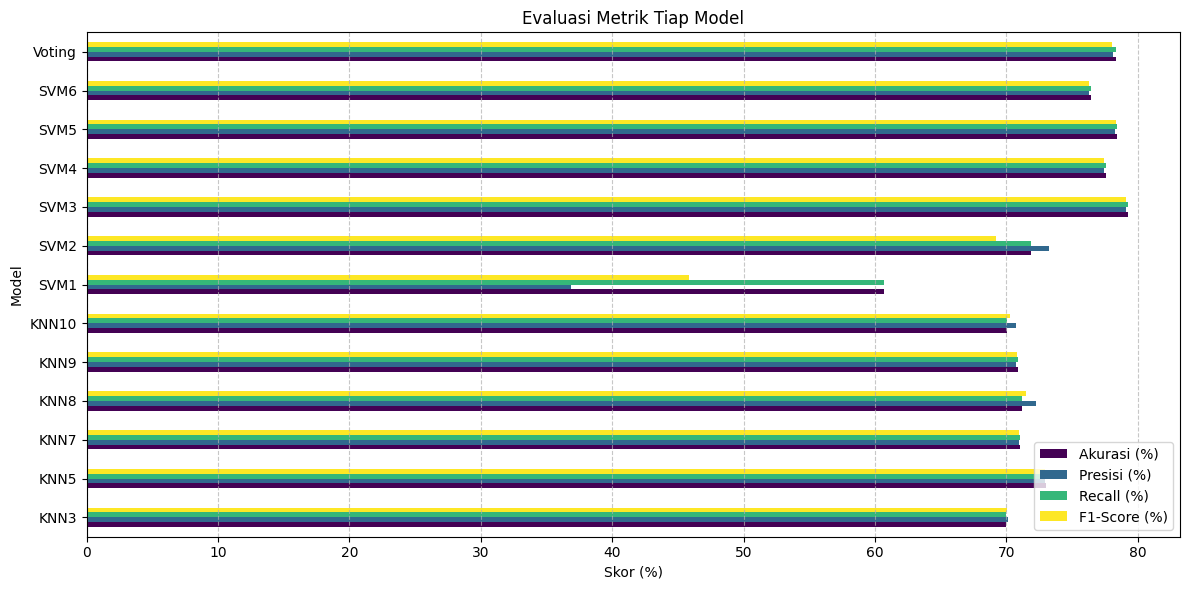

In [ ]:
# Plot akurasi, presisi, recall, dan F1-score
plt.figure(figsize=(12, 6))
eval_df.plot(kind='barh', figsize=(12, 6), colormap='viridis')
plt.title('Evaluasi Metrik Tiap Model')
plt.xlabel('Skor (%)')
plt.ylabel('Model')
plt.legend(loc='lower right')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# MENGHITUNG PERFORMANCE PREDIKSI MODEL ENSEMBEL
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

kfold = KFold(n_splits=10)
scores = ['accuracy', 'precision', 'recall', 'f1']
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label='Positive'),
    'recall': make_scorer(recall_score, pos_label='Positive'),
    'f1': make_scorer(f1_score, pos_label='Positive')
}
results = cross_validate(ensemble, X_train_tfidf, y_train, cv=kfold, scoring=scoring, return_train_score=False) # Use X_train_tfidf here
results_data = pd.DataFrame(results)
results_data

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,60.335178,1.025837,0.773438,0.794466,0.851695,0.822086
1,59.852115,1.033253,0.755208,0.764940,0.845815,0.803347
2,59.851803,1.019704,0.734375,0.768000,0.813559,0.790123
3,60.269283,1.028367,0.781250,0.802372,0.856540,0.828571
4,59.631104,1.354249,0.754569,0.816000,0.809524,0.812749
5,60.160187,1.091122,0.725849,0.787879,0.809339,0.798464
6,60.325515,1.061234,0.738903,0.799163,0.786008,0.792531
7,61.414030,1.036829,0.806789,0.874494,0.833977,0.853755
8,60.090794,1.037952,0.762402,0.776515,0.864979,0.818363
9,60.510511,1.054623,0.762402,0.781746,0.845494,0.812371


In [ ]:
print("PERFORMANCE MODEL ENSEMBLE DENGAN METODE HARD VOTING")

# Menyimpan hasil rata-rata untuk accuracy, precision, recall, dan f1-score
accuracy = results_data['test_accuracy'].mean() * 100
precision = results_data['test_precision'].mean() * 100
recall = results_data['test_recall'].mean() * 100
f1_score = results_data['test_f1'].mean() * 100

# Menampilkan hasil
print("Accuracy : %0.2f " % accuracy, "%")
print("Precision : %0.2f " % precision, "%")
print("Recall : %0.2f " % recall, "%")
print("F1-score : %0.2f " % f1_score, "%")

PERFORMANCE MODEL ENSEMBLE DENGAN METODE HARD VOTING
Accuracy : 75.95  %
Precision : 79.66  %
Recall : 83.17  %
F1-score : 81.32  %


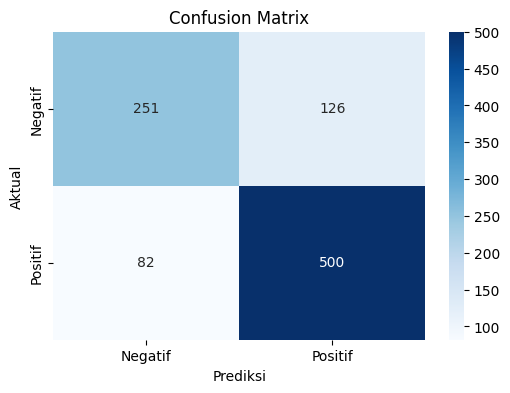

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.67      0.71       377
    Positive       0.80      0.86      0.83       582

    accuracy                           0.78       959
   macro avg       0.78      0.76      0.77       959
weighted avg       0.78      0.78      0.78       959



In [ ]:
# Menampilkan Confusion Matrix
from sklearn.metrics import classification_report
cm = confusion_matrix(y_test, voting_pred4)

# Menampilkan Confusion Matrix sebagai Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

# Menampilkan classification report (precision, recall, f1-score per kelas)
print("Classification Report:")
print(classification_report(y_test, voting_pred4))